<a href="https://colab.research.google.com/github/RGarancs/applied-ai-academy-labs/blob/main/solutions/abtest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Marketing A/B test (2,400 users)

**Applied AI Academy — problem set with worked answers**

**Used in:** Lesson 15 — Fund workflows, not pilots: portfolio discipline beats enthusiasm  
**Rows:** 2,400  ·  **Source file:** `marketing_ab_test.csv`



---
### How to use this notebook
Run the cells in order. Each problem is stated first, then solved, then the
answer is spelled out. For teaching, hide the solution cells and let the room
attempt the task before revealing them.

> The data loads straight from `appliedai.center` — nothing to upload.


## Setup

In [1]:
%matplotlib inline
import pandas as pd, numpy as np, os, urllib.request
import matplotlib, matplotlib.pyplot as plt
pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 40)

# Applied AI Academy chart style — calm, legible when projected
INK, ACCENT, CORE, BUILDER, DANGER = "#26214a", "#544d94", "#5b8a6e", "#a8845c", "#b05a5a"
matplotlib.rcParams.update({
    "figure.figsize": (9, 4.5), "figure.dpi": 110,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": "#c9c4d8", "axes.labelcolor": INK, "axes.titlesize": 13,
    "axes.titleweight": "600", "axes.titlecolor": INK, "axes.titlepad": 14,
    "text.color": INK, "xtick.color": INK, "ytick.color": INK,
    "font.size": 10, "grid.color": "#e6e2ef", "axes.grid": True,
    "axes.axisbelow": True, "grid.linewidth": .8, "figure.facecolor": "white",
})

URL   = "https://appliedai.center/assets/datasets/marketing_ab_test.csv"
LOCAL = "marketing_ab_test.csv"
if not os.path.exists(LOCAL):
    print("Downloading", URL)
    urllib.request.urlretrieve(URL, LOCAL)

df = pd.read_csv(LOCAL, low_memory=False)
print("Shape:", df.shape)
df.head()

Shape: (2400, 6)


,user_id,variant,user_type,channel,converted,revenue_eur
0,U0001,A,new,email,1,62.0
1,U0002,B,new,email,0,0.0
2,U0003,A,new,email,0,0.0
3,U0004,B,returning,email,0,0.0
4,U0005,A,new,direct,0,0.0


## What is in the file

In [2]:
print("Columns and types:")
print(df.dtypes.to_string())
miss = df.isna().sum()
miss = miss[miss > 0]
print("\nMissing values:" if len(miss) else "\nNo missing values.")
if len(miss): print(miss.to_string())

Columns and types:
user_id            str
variant            str
user_type          str
channel            str
converted        int64
revenue_eur    float64

No missing values.


---
## Problem 1 · Easy — describe

Read the headline result.

*Try it yourself first. The worked solution is below.*

In [3]:
res = (df.groupby("variant")
         .agg(users=("user_id","size"), conversions=("converted","sum"),
              conv_rate=("converted","mean"), revenue=("revenue_eur","sum"))
         .round(4))
res["conv_rate_%"] = (res["conv_rate"]*100).round(2)
print(res)
a, b = res.loc["A","conv_rate"], res.loc["B","conv_rate"]
print(f"\nNaive read: B beats A by {(b-a)*100:.2f} percentage points.")

         users  conversions  conv_rate  revenue  conv_rate_%
variant                                                     
A         1200           48      0.040  3202.67          4.0
B         1200           66      0.055  4012.70          5.5

Naive read: B beats A by 1.50 percentage points.


---
## Problem 2 · Intermediate — build

Now split by user type — and watch the result change.

*Try it yourself first. The worked solution is below.*

In [4]:
seg = (df.groupby(["user_type","variant"])
         .agg(users=("user_id","size"), conv_rate=("converted","mean")).round(4))
seg["conv_rate_%"] = (seg["conv_rate"]*100).round(2)
print(seg)

print("\nLift within each segment (B - A, percentage points):")
for ut in df["user_type"].unique():
    s = df[df["user_type"] == ut]
    a = s[s.variant=="A"]["converted"].mean(); b = s[s.variant=="B"]["converted"].mean()
    print(f"  {ut:<12} {(b-a)*100:+.2f} pp")

print("\nMix check — how the variants were split across user types:")
print(pd.crosstab(df["user_type"], df["variant"], normalize="columns").round(3))

                   users  conv_rate  conv_rate_%
user_type variant                               
new       A          762     0.0302         3.02
          B          529     0.0302         3.02
returning A          438     0.0571         5.71
          B          671     0.0745         7.45

Lift within each segment (B - A, percentage points):
  new          +0.01 pp
  returning    +1.74 pp

Mix check — how the variants were split across user types:
variant        A      B
user_type              
new        0.635  0.441
returning  0.365  0.559


---
## Problem 3 · Advanced — judge

Test significance, then decide what you would actually tell the business.

*Try it yourself first. The worked solution is below.*

In [5]:
from scipy import stats
tab = pd.crosstab(df["variant"], df["converted"])
chi2, p, _, _ = stats.chi2_contingency(tab)
print(f"Overall chi-square p-value: {p:.4f}")

for ut in df["user_type"].unique():
    s = df[df["user_type"] == ut]
    t = pd.crosstab(s["variant"], s["converted"])
    if t.shape == (2,2) and t.values.min() >= 5:
        _, pp, _, _ = stats.chi2_contingency(t)
        print(f"  {ut:<12} p = {pp:.4f}")

print("\nThis is Simpson's paradox: an aggregate lift that is really a mix effect.")
print("Report the segmented result, or you will ship a change that does nothing.")

Overall chi-square p-value: 0.1028
  new          p = 1.0000
  returning    p = 0.3134

This is Simpson's paradox: an aggregate lift that is really a mix effect.
Report the segmented result, or you will ship a change that does nothing.


---
## Visual summary

The same answers, as pictures. These are what to project — a room reads a chart
far faster than it reads a table, and the shape of a result is usually the
argument you are actually making.

findfont: Failed to find font weight 600, now using 700.


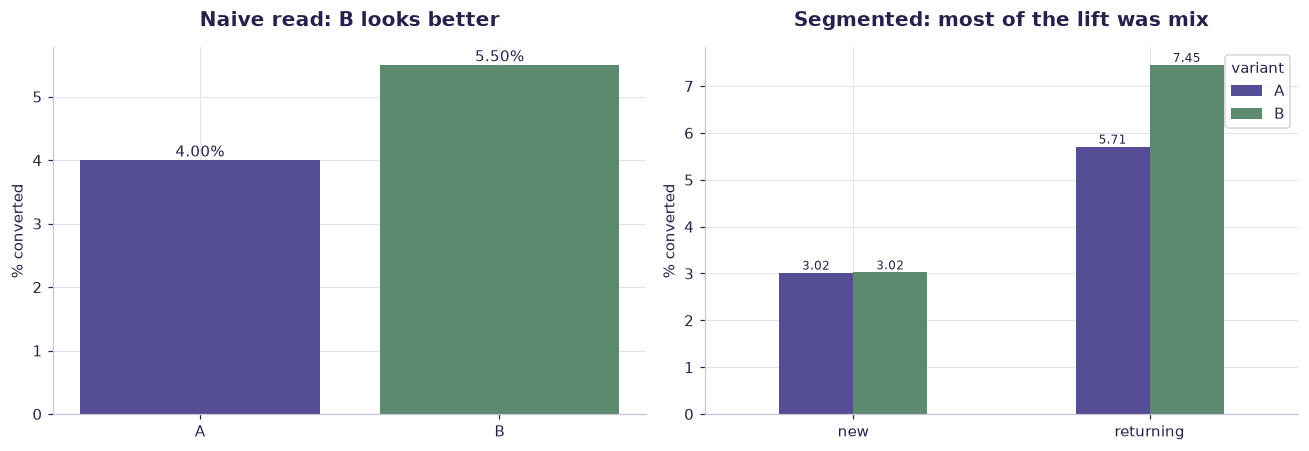

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))
o = df.groupby("variant")["converted"].mean().mul(100)
b = ax[0].bar(o.index, o.values, color=[ACCENT, CORE])
ax[0].bar_label(b, fmt="%.2f%%", fontsize=10)
ax[0].set_title("Naive read: B looks better"); ax[0].set_ylabel("% converted")

seg = df.groupby(["user_type","variant"])["converted"].mean().mul(100).unstack()
seg.plot(kind="bar", ax=ax[1], color=[ACCENT, CORE], rot=0)
ax[1].set_title("Segmented: most of the lift was mix"); ax[1].set_ylabel("% converted"); ax[1].set_xlabel("")
for c in ax[1].containers: ax[1].bar_label(c, fmt="%.2f", fontsize=8)
plt.tight_layout(); plt.show()

---
## Verified answer key

These are the numbers the academy ships for this dataset. They were computed
from this exact file — if your run disagrees, reconcile before teaching it.

1. Naive read: A 4.00% vs B 5.50% — "B wins by +1.5pp!"
2. Segmented: NEW users A 3.02% vs B 3.02% — zero difference; RETURNING A 5.71% vs B 7.45%
3. The trap: B's traffic skews returning (55% vs 35%) — part of its naive lift is mix, not effect
4. The honest conclusion: B genuinely helps returning users; for new users it does nothing — segment before you ship


---
## Teaching notes

* **Run the Easy problem live.** It sets the shared vocabulary and gets everyone
  looking at the same rows.
* **Let them fail on the Intermediate one.** The productive mistake is usually
  reaching for a model before checking the data.
* **Argue about the Advanced one.** It has no single right answer; it has a
  defensible one, and defending it is the skill being taught.
* **Always close on limitations.** Every dataset here has a real caveat —
  scrape bias, a tiny sample, a hindsight label. Naming it is the lesson.
* **Deliverable for learners:** ROI model v1 + prioritised portfolio with one explicit stop decision.

---
*Applied AI Academy · appliedai.center*
